<a href="https://colab.research.google.com/github/mariaaapetrovskaya/compling_nlp_course/blob/main/02_homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Задание 1. (1 балл)

Посчитайте частоты для 5-грамм в корпусе lenta.txt. двумя способами:  
1) Текст токенизируется в один сплошной список токенов и нграммы считаются по всем токенам без учета границ предложений
2) Текст разбивается на предложения, а каждое предложение на токены; нграммы собираются с учетом границ предложений
    
Найдите различия между топ 100 нграммов для первого и второго способов

In [5]:
def ngrammer(tokens, n=2):
    ngrams = []
    for i in range(len(tokens) - n + 1):
        ngrams.append(tuple(tokens[i:i+n]))
    return ngrams

In [6]:
from nltk import word_tokenize, sent_tokenize
from collections import Counter

with open('lenta.txt', encoding='utf-8') as f:
    corpus = f.read()


tokens = word_tokenize(corpus, language='russian')
tokens = [word.lower() for word in tokens if word.isalpha()]

ngrams_1 = Counter(ngrammer(tokens, n=5))

sentences = sent_tokenize(corpus, language='russian')
sent_tokens = [
    [word.lower() for word in word_tokenize(sentence, language='russian')
     if word.isalpha()]
    for sentence in sentences
]

ngrams_2 = Counter()
for sentence in sent_tokens:
    ngrams_2.update(ngrammer(sentence, n=5))

top_1 = set(dict(ngrams_1.most_common(100)))
top_2 = set(dict(ngrams_2.most_common(100)))

print("Только в 1:")
print(top_1 - top_2)

print("Т во 2:")
print(top_2 - top_1)

Только в 1:
{('передает', 'риа', 'новости', 'по', 'словам'), ('сообщает', 'риа', 'новости', 'по', 'словам'), ('сообщает', 'риа', 'новости', 'по', 'данным'), ('в', 'по', 'московскому', 'времени', 'в')}
Т во 2:
{('со', 'ссылкой', 'на', 'правоохранительные', 'органы'), ('получили', 'ранения', 'различной', 'степени', 'тяжести'), ('об', 'этом', 'заявил', 'в', 'среду'), ('по', 'борьбе', 'с', 'экономическими', 'преступлениями')}


Без учета границ предложений есть сочетания, которые могут пересекать границы предложений. А с учетом границ предложения такого нет. Навернок, поэтому топ 100 нграммов отличаются

## Задание 2. (1 балл)

Найдите какую-то инетересную (по вашему мнению) закономерность на https://books.google.com/ngrams/ для русского языка (с 1990 по 2022)

Вставьте сюда скриншот

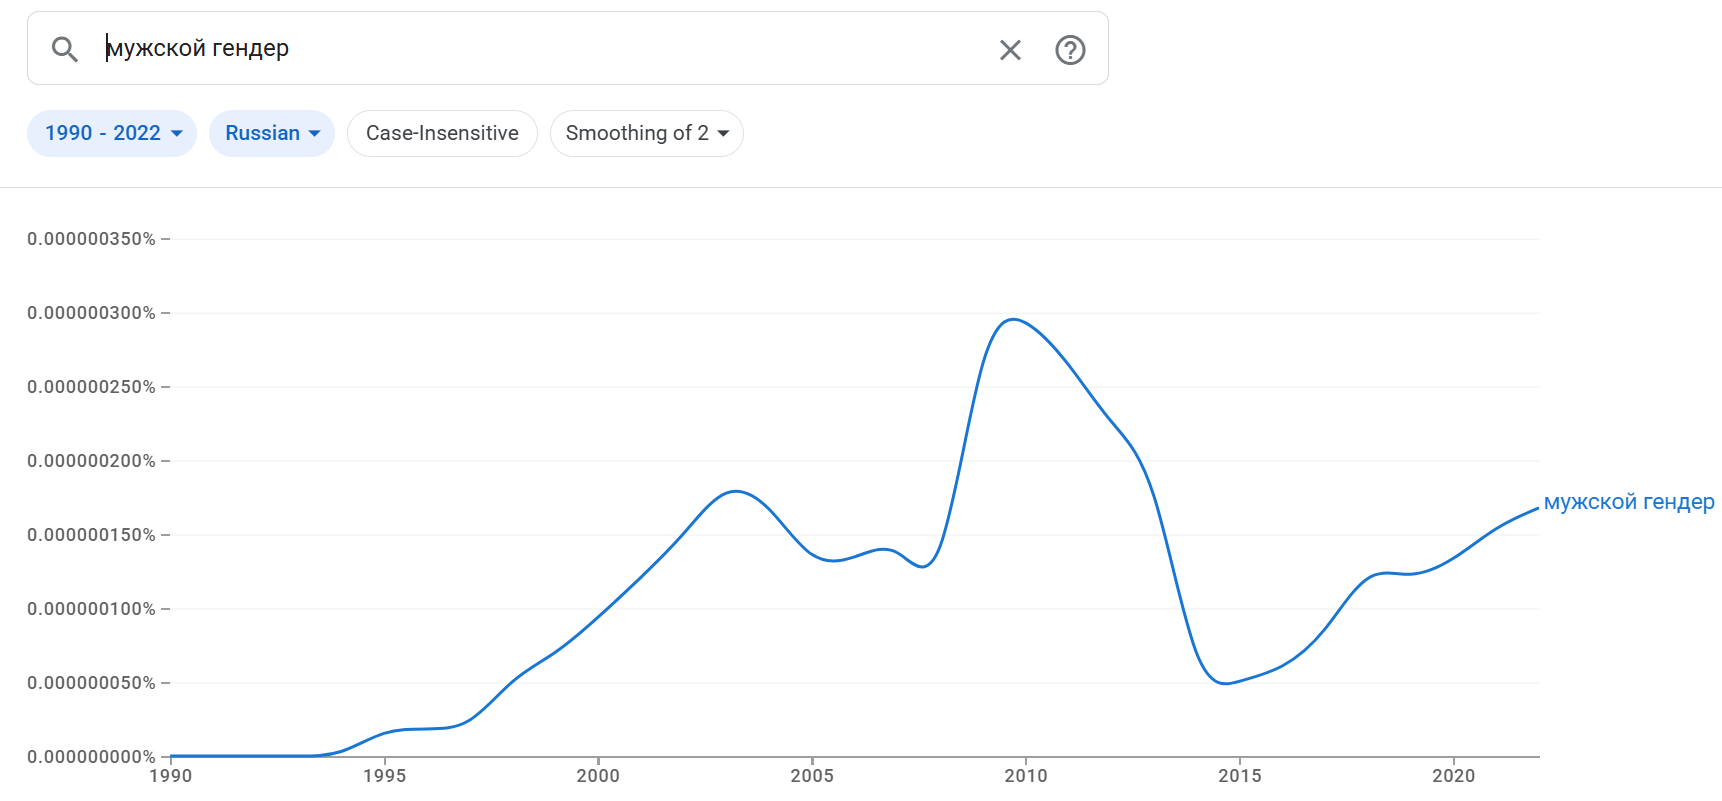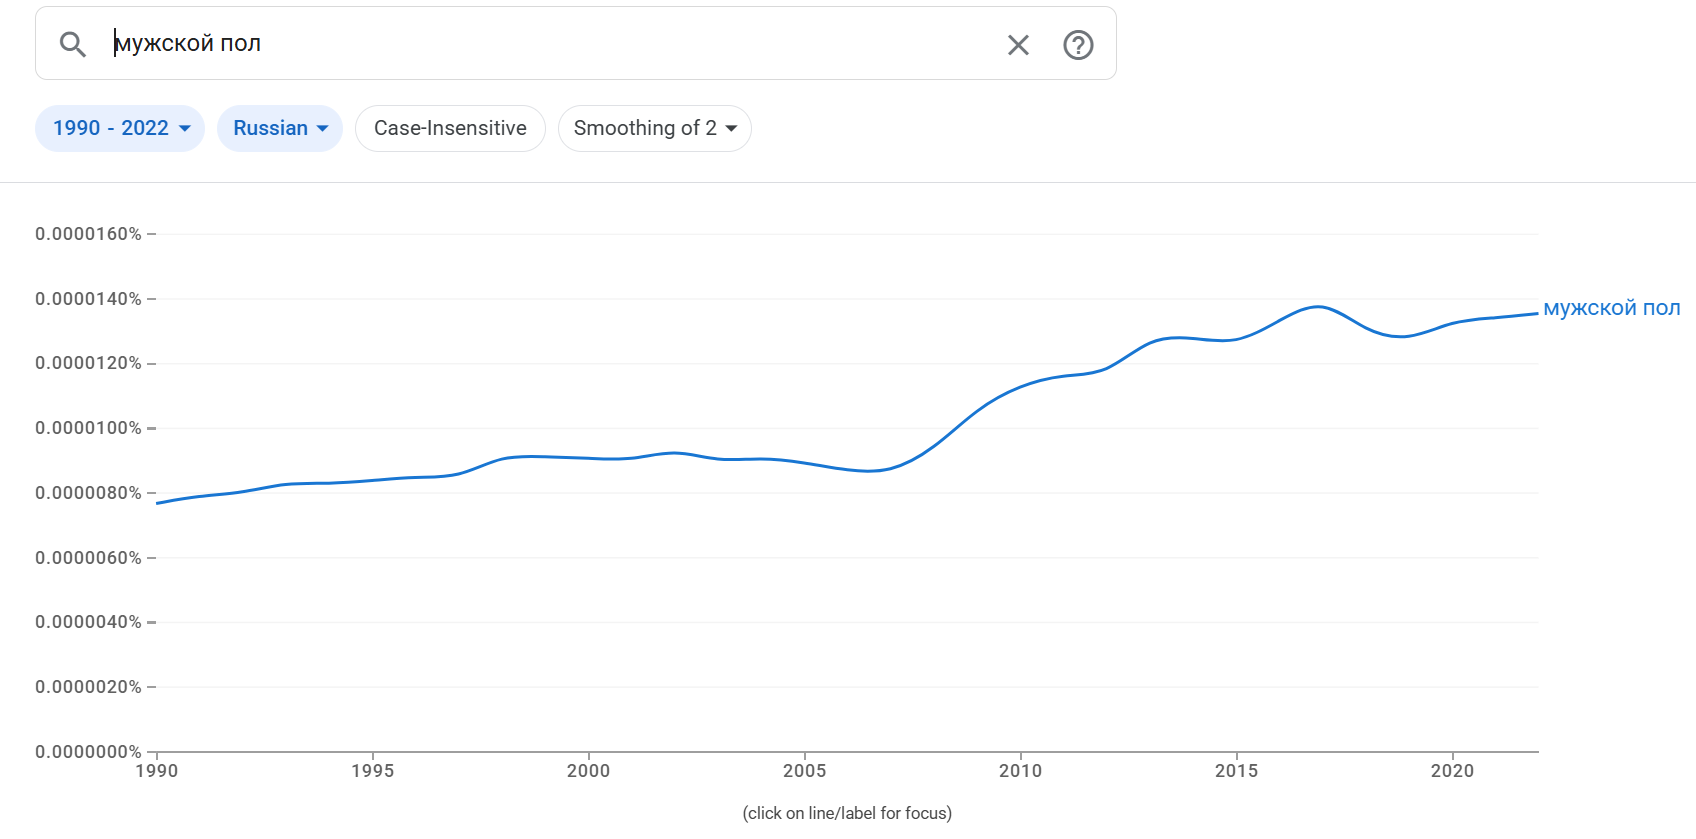

## Заданиe 3 (1 балл)

В семинаре мы использовали Dice coefficient (`score = 2 * bigram_count/((word_count_a+word_count_b))`) для нахождения коллокаций.
Но самая известная метрика для этого другая - [PMI](https://en.wikipedia.org/wiki/Pointwise_mutual_information). Имплементируйте скоринг с помощью этой метрики и сравните результаты с Dice на топ 30 биграмах.
Используйте логарифмы для работы с вероятностями.

In [17]:
def scorer_pmi(*args):
    try:
        score = ...
    except ZeroDivisionError:
        return 0
    return score

In [26]:
import math
from collections import Counter

import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [27]:
russian_stopwords = stopwords.words('russian')

In [28]:
def ngrammer(tokens, n=2, stops=set()):
    ngrams = []
    tokens = [token for token in tokens if token not in stops]

    for i in range(0, len(tokens) - n + 1):
        ngrams.append(' '.join(tokens[i:i+n]))

    return ngrams

In [29]:
def collect_stats(corpus, stops):
    unigrams = Counter()
    bigrams = Counter()

    for sent in corpus:
        unigrams.update(sent)
        bigrams.update(ngrammer(sent, 2, stops))

    return unigrams, bigrams

In [30]:
def score_bigrams(unigrams, bigrams, scorer, threshold=-100000):
    bigram2score = Counter()

    for bigram in bigrams:
        word_a, word_b = bigram.split()

        score = scorer(
            unigrams[word_a],
            unigrams[word_b],
            bigrams[bigram]
        )

        if score > threshold:
            bigram2score[bigram] = score

    return bigram2score

In [31]:
unigrams, bigrams = collect_stats(
    tokenized_sentences,
    russian_stopwords
)

In [32]:
def scorer_simple(word_count_a, word_count_b, bigram_count):
    try:
        score = (2 * bigram_count) / (word_count_a + word_count_b)
    except ZeroDivisionError:
        return 0

    return score

In [33]:
bigram2score_dice = score_bigrams(
    unigrams,
    bigrams,
    scorer_simple
)

bigram2score_dice.most_common(30)

[('Сопоцкина Друскеник', 1.0),
 ('М.Ю. Лермонтова', 1.0),
 ('австрийский аэроплан', 1.0),
 ('показывался аэроплан-птица', 1.0),
 ('Das ist', 1.0),
 ('ist Nesteroff', 1.0),
 ('Песнь Нестерове', 1.0),
 ('зловеще гремели.И', 1.0),
 ('гремели.И пламенно', 1.0),
 ('пламенно богу', 1.0),
 ('жаждали битвы…Величие', 1.0),
 ('равнине обманчиво-зыбкой.Презрение', 1.0),
 ('светлою солнца', 1.0),
 ('солнца улыбкой…Мольбы', 1.0),
 ('воздушнойИ дрогнуло', 1.0),
 ('пружина стальная', 1.0),
 ('Решенье созрелоМгновенье', 1.0),
 ('дерзко хрупкое', 1.0),
 ('хрупкое тело.Пощады', 1.0),
 ('спрятанными ошейнике', 1.0),
 ('ошейнике шифрованные', 1.0),
 ('шифрованные депеши', 1.0),
 ('трусливо замешался', 1.0),
 ('запирая хатах', 1.0),
 ('140- тонный', 1.0),
 ('1-ая Градская', 1.0),
 ('36-ая 64-ая', 1.0),
 ('64-ая горбольница', 1.0),
 ('золоченым воротамКенсингтонского', 1.0),
 ('поклонники.В чугунные', 1.0)]

In [34]:
def scorer_pmi(word_count_a, word_count_b, bigram_count):
    try:
        total_count = sum(unigrams.values())

        score = math.log(
            (bigram_count * total_count) /
            (word_count_a * word_count_b)
        )
    except ZeroDivisionError:
        return 0

    return score

In [36]:
bigram2score_pmi = Counter()

total_count = sum(unigrams.values())

for bigram, count in bigrams.items():
    if count < 20:
        continue

    word_a, word_b = bigram.split()

    score = math.log(
        (count * total_count) /
        (unigrams[word_a] * unigrams[word_b])
    )

    bigram2score_pmi[bigram] = score

bigram2score_pmi.most_common(30)

[('exit polls', 11.17150219217165),
 ('Духовное наследие', 11.159573621306375),
 ('Норильский никель', 11.130680197651394),
 ('взрывном устройстве', 11.09454115103552),
 ('подписные листы', 11.058173506864646),
 ('Dow Jones', 11.023082187053376),
 ('Эхуд Барак', 10.956390812554703),
 ('Кофи Аннан', 10.849418693002535),
 ('Манчестер Юнайтед', 10.848728799908598),
 ('Амана Тулеева', 10.817497476788795),
 ('смертной казни', 10.796808742730239),
 ('подписных листов', 10.71883548257919),
 ('Восточного Тимора', 10.65270839875648),
 ('террористического акта', 10.639698162020466),
 ('шкале Рихтера', 10.629177901346287),
 ('Верховной Рады', 10.629177901346287),
 ('Саудовской Аравии', 10.62679552976088),
 ('Восточном Тиморе', 10.616181328519106),
 ('Персидском заливе', 10.606188383121589),
 ('мобильном отряде', 10.597604639430196),
 ('следственный изолятор', 10.56796717030139),
 ('General Motors', 10.565697021766852),
 ('следственном изоляторе', 10.487628648397033),
 ('Борису Ельцину', 10.479355

# Задание 4 (2 балл)

Шаг 1: Измените функцию merge_round так чтобы она использовала скоринг, который вы сделаете в задании выше.
Шаг 2: Подберите параметры (min_count, n_merges, n_rounds) так чтобы получались адекватные результаты
Шаг 3: Сохраните промежуточные словари мержей и напишите функцию, которая их последовательно применяет, чтобы иметь возможности воспроизвести трансформацию на любой новом тексте

Подберите несколько предложений, на которых функция трансформации будет склеивать хотя бы несколько слов вместе

In [ ]:
saved_merged = []
for round_i in range(1, 10):
    sub_corpus, merges = merge_round(sub_corpus)
    saved_merged.append(merges)



def apply_merges(text, merges):
    ...
    return merged_text


new_text =  tokenize("Какой-то новый текст")
apply_merges(new_text)

In [41]:
import math
from collections import Counter



def merge_round(corpus, min_count=20, n_merges=1000):


    u = Counter(t for s in corpus for t in s)


    b = Counter()
    for s in corpus:
        b.update(zip(s, s[1:]))


    total_count = sum(u.values())
    scores = {}

    for (w1, w2), c in b.items():
        if c >= min_count:
            scores[(w1, w2)] = math.log(
                (c * total_count) /
                (u[w1] * u[w2])
            )


    best = set(
        sorted(
            scores,
            key=scores.get,
            reverse=True
        )[:n_merges]
    )

    merged = []

    for s in corpus:
        ws = []

        for i in range(0, len(s) - 1, 2):
            w1, w2 = s[i], s[i + 1]

            if (w1, w2) in best:
                ws.append(w1 + "_" + w2)
            else:
                ws.extend([w1, w2])


        if len(s) % 2 == 1:
            ws.append(s[-1])

        merged.append(ws)

    return merged, sorted(
        scores,
        key=scores.get,
        reverse=True
    )[:n_merges]




min_count = 20
n_merges = 1000
n_rounds = 5



sub_corpus = [list(s) for s in tokenized_sentences[:30000]]



saved_merged = []

for round_i in range(n_rounds):

    sub_corpus, merges = merge_round(
        sub_corpus,
        min_count=min_count,
        n_merges=n_merges
    )

    saved_merged.append(merges)

    print(
        f"Раунд {round_i + 1}: "
        f"{len(merges)} merges; "
        f"первый: {merges[0] if merges else 'нет'}"
    )




def apply_merges(text, merges):

    merged_text = text

    for round_merges in merges:

        best = set(round_merges)
        result = []

        i = 0

        while i < len(merged_text) - 1:

            w1 = merged_text[i]
            w2 = merged_text[i + 1]

            if (w1, w2) in best:
                result.append(w1 + "_" + w2)
                i += 2
            else:
                result.append(w1)
                i += 1


        if i < len(merged_text):
            result.append(merged_text[i])

        merged_text = result

    return merged_text



new_text = word_tokenize(
    "Еврокомиссия призвала страны ЕС принудительно сократить потребление газа и электричества",
    language="russian"
)

print(apply_merges(new_text, saved_merged))

Раунд 1: 1000 merges; первый: ('Wall', 'Street')
Раунд 2: 1000 merges; первый: ('РАО_``', 'ЕЭС_России')
Раунд 3: 891 merges; первый: ('``_Отечество_-_Вся', "Россия_''")
Раунд 4: 295 merges; первый: ('``_Эхо', "Москвы_''")
Раунд 5: 180 merges; первый: ('``_Эхо', "Москвы_''")
['Еврокомиссия', 'призвала', 'страны', 'ЕС', 'принудительно', 'сократить', 'потребление', 'газа', 'и', 'электричества']


In [43]:
for sentence in tokenized_sentences[:1000]:

    result = apply_merges(sentence, saved_merged)

    if sum("_" in token for token in result) >= 3:

        print("Исходн:")
        print(" ".join(sentence))

        print("\nПосл merges:")
        print(" ".join(result))

        print("\n" + "-" * 80 + "\n")

Исходн:
« Русский инвалид » , 16 сентября 1914 года.Министерство народного просвещения , в виду происходящих чрезвычайных событий , признало соответственным в день годовщины со дня рождения М.Ю. Лермонтова ( 2-го октября 1914 года ) ограничиться совершением в учебных заведениях панихиды по поэту , отложив празднование юбилея до более благоприятного времени .

Посл merges:
« Русский инвалид » , 16 сентября 1914 года.Министерство народного просвещения ,_в виду происходящих чрезвычайных событий , признало соответственным в_день годовщины со_дня рождения М.Ю. Лермонтова ( 2-го октября 1914 года ) ограничиться совершением в учебных заведениях панихиды по поэту , отложив празднование юбилея до более благоприятного времени_.

--------------------------------------------------------------------------------

Исходн:
« Русский инвалид » , 16 сентября 1914 года.Штабс-капитан П. Н. Нестеров на днях , увидев в районе Желтиева , в Галиции , летящий над нашим расположением австрийский аэроплан , соби

# Задание 5 (3 балла)

Напишите краткое эссе (30 - 50 предложений) в свободной форме по одной из этих статей:
1) https://news.microsoft.com/source/2026/09/09/aft-uft-and-microsoft-announce-national-ai-safety-privacy-standard-for-schools-to-protect-students-families-and-educators/ и сам целый документ https://www.aft.org/sites/default/files/media/documents/2026/NAfAI-School_AI_Privacy_Standards.pdf
2) https://bayareacurrent.com/theres-a-lot-of-cleaning-up-poop-a-depot-worker-on-the-human-labor-behind-waymos-autonomous-vehicles/

Эту часть достаточно сложно оценивать формально, но я ожидаю увидеть ваши содержательные рассуждения о написанном в статье.   
Если после прочтения вам ничего не приходит в голову, то вы можете начать со следующих вопросов: Считаете ли вы эту информацию важной/интересной/страшной/скучной/и тп? Что показалось вам наиболее важным? Почему? Считаете ли вы эту статью объективной? Какие пробелы вы видите? По вашему мнению будет ли продолжение у этих историй? В каком направлении они будут развиваться? Считаете ли вы age restriction необходимым для AI моделей? (для первой статьи) Как можно предотвращать/бороться с подобным антисоциальным поведением в автономных автомобилях? (для второй) ...
Но это не полный и не обязательный список! Вы можете писать о всем, что вы посчитаете нужным.

Чего точно следует избегать:
1) Не пишите саммари! Ваше эссе должно выражать ваши собственные мысли и добавлять что-то к тексту, а не заменять его.
2) Не гонитесь за полнотой! Можно и нужно опускать детали. Вы даже можете даже сфокусироваться только на каком-то одном аспекте статьи и порассуждать о нем поглубже.
3) Не отвлекайтесь на форматирование! Не используйте нумерованные списки, булет пойнты, ссылки и т.п. Напишите все как один связанный plain текст (можете разбить все на параграфы, но не более того)
4) Не объясняйте термины и понятия, не давайте определений! Считайте, что читатель знает столько же, сколько вы или же что он может погуглить.
5) Не уходите от темы! Реагируйте только на сам текст, а не на общий контекст (схожие события и работы, реакция в сотсетях и т.п). Не сравнивайте с другими статьями от того же Антропика или OpenAI.
6) Не бойтесь выражать мнение! Но либо обосновывайте его, либо описиваете свои ощущения в деталях.
7) Будьте осторожными с bias. Не списывайте все на капитализм, AI buble, AI doomerism, AI accerationalism и тому подобные слишком общие и абстрактные вещи. Не выражайте ваше личное отношение к авторам (антропику), только к содержанию статьи!



https://bayareacurrent.com/theres-a-lot-of-cleaning-up-poop-a-depot-worker-on-the-human-labor-behind-waymos-autonomous-vehicles/

После прочтения статьи, как мне кажется, сложно не уйти в обобщения. Сейчас невидимый труд это системная проблема, которую сложно не связать с капитализмом и технологическим позитивизмом. При другом распределении доходов и собственности, возможно, автоматизация и ее последствия выглядели бы по-другому.

Из статьи нам известно, что несмотря на автономность поездок, автомобиль все еще обслуживают сотрудники. При этом сама беспилотная технология пока недостаточно эффективна и совершенна, из-за чего сотрудникам приходится собственноручно добираться до автомобилей и чинить их. Сама рабочая иерархия, как ни странно, тоже оказывается не такой совершенной, и сотрудникам приходится неравномерно выполнять обязанности.

Говоря кратко, автоматизация просто меняет форму труда и прячет его от глаз потребителей, которым должно быть комфортно ездить на автомобиле, который never “gets tired, angry, or distracted”. Мне кажется интересным, что в общественных дискуссиях на тему технологического развития и AI часто критикуют обесценивание интеллектуального труда писателей, художников и других представителей творческих профессий, но одной из важных проблем как раз является «невидимая» работа по обслуживанию таких систем.

Если думать об образе будущего, который часто возникает у обывателей, то это автономные летающие машины, дроны, выполняющие работу человека. Мне кажется, фантазия о техническом прогрессе сталкивается с реальностью, описанной в статье.

Последнее, о чем я хотела бы упомянуть, это цитата, которая мне особенно приглянулась: «Waymo envisions itself as already welcoming you to a future in which you will own a self-driving car that, as Waymo claims, never “gets tired, angry, or distracted”». В этом есть что-то интересное с точки зрения постгуманистической теории. В рекламном тексте автомобиль одновременно наделяют человеческими качествами и убирают самые «неприятные»: злость, усталость, возможность отвлечься. Новые автомобили заменяют водителя, специально подчеркивая преимущества полного контроля и комфорта вместо человеческой сложности и непредсказуемости, которые невозможно полностью контролировать.